# Baseline: hierarkisk multi-head CNN (nivå 1 + nivå 2)

Denne notebooken bygger videre på de ferdige `train/val/test`-splittene og trener en enkel baseline-modell:

- **Nivå 1**: `Tesla` vs `Other` (binary)
- **Nivå 2**: Tesla-underklasser (sparse categorical), **maskert for `Other`** med `sample_weight`.

## Forutsetninger
- Du har `datasplitt/train.csv`, `val.csv`, `test.csv`.
- CSV-ene inneholder minst: `image`, `model`, `lighting`.
- `image` er relativ sti under `IMG_ROOT` (datasett-roten). I denne repo-strukturen settes IMG_ROOT = PROJECT_ROOT / "datasett_src".

## Steg i denne notebooken
- Leser datasplitt (train/val/test) fra `datasplitt/`.
- Forbereder labels og sample weights for hierarkisk trening.
- Bygger `tf.data` pipeline med robust bildekoding.
- Trener en enkel baseline-modell med to output-hoder (nivå 1 og nivå 2).
- Evaluerer totalt og per lyskategori.

### Imports og grunnkonfigurasjon

Importerer nødvendige biblioteker og setter grunnparametre (seed, bildeformat, batch-størrelse).

In [1]:
# 0) Imports
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

print("TensorFlow:", tf.__version__)

2026-02-27 15:15:54.836786: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-27 15:15:55.393484: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-27 15:16:06.498342: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.20.0


### Les datasplitt (train/val/test)

Finner prosjektroten og leser `train.csv`, `val.csv` og `test.csv` fra `datasplitt/`. Viser en rask oversikt over datasettet.

In [2]:
# 1) Konfig

# Vi bruker `annotations/combined_clean_onedrive.csv` som anker for å finne riktig prosjektrot.
# Splittene forventes å være lagret av test_split.ipynb i mappen `datasplitt/`.

SEED = 42
IMG_SIZE = (300, 300)   # Juster om dereen vil bruke annet format  (224, 224 er vanlig for mange pre-trente modeller)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

tf.random.set_seed(SEED)
np.random.seed(SEED)

# Finn prosjektrot robust (forutsetter at mappen 'annotations' finnes)
cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    p for p in [cwd, *cwd.parents]
    if (p / "annotations" / "combined_clean_strict.csv").exists()
)

SPLIT_DIR = PROJECT_ROOT / "datasplitt"
TRAIN_CSV = SPLIT_DIR / "train.csv"
VAL_CSV   = SPLIT_DIR / "val.csv"
TEST_CSV  = SPLIT_DIR / "test.csv"

if not (TRAIN_CSV.exists() and VAL_CSV.exists() and TEST_CSV.exists()):
    raise FileNotFoundError("Finner ikke train/val/test i datasplitt/.")

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SPLIT_DIR:", SPLIT_DIR)
print("rows train/val/test:", len(train_df), len(val_df), len(test_df))
print("columns:", train_df.columns.tolist())
display(train_df.head())

PROJECT_ROOT: /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions
SPLIT_DIR: /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt
rows train/val/test: 3033 650 651
columns: ['color', 'image', 'lighting', 'model', 'source', 'year', 'lvl1', 'lvl2', 'strat_key']


,color,image,lighting,model,source,year,lvl1,lvl2,strat_key
0,Red,Eksternt/Tesla/daylight/Kaggle/S/images - 2023...,Light,S 2012–2015,external,2012–2015,Tesla,S 2012–2015,Tesla|S 2012–2015|Light
1,Light gray/Silver,Eksternt/non-tesla/daylight/0814_01435.jpg,Light,Other car,external,NaN,Other,NaN,Other|NA|Light
2,Light gray/Silver,Eksternt/non-tesla/daylight/0689_04020.jpg,Light,Other car,external,NaN,Other,NaN,Other|NA|Light
3,Light gray/Silver,Egenprodusert/Tesla/low-light/IMG_1424.jpg,Medium,3 2017–2023,internal,2017–2023,Tesla,3 2017–2023,Tesla|3 2017–2023|Medium
4,Black/Dark gray,Egenprodusert/Tesla/daylight/%~n1-495.jpg,Light,Y 2025-nå,internal,2025-nå,Tesla,Y 2025-nå,Tesla|Y 2025-nå|Light


### Angi bildemappe (IMG_ROOT)

Setter rotmappen der bildefilene ligger. Stiene i `image`-kolonnen i CSV er **relative** til denne mappen.

In [3]:
# 2) Last split CSV-er

# Viktig: `IMG_ROOT / <image>` må peke til en faktisk fil på disk.
# Eksempelstier i CSV kan være som: Eksternt/Tesla/... eller Egenprodusert/...
# 2) Sett IMG_ROOT (datasett-roten som 'image' er relativ til)
IMG_ROOT = PROJECT_ROOT / "datasett_src"
print("IMG_ROOT:", IMG_ROOT)
print("IMG_ROOT exists:", IMG_ROOT.exists())

if not IMG_ROOT.exists():
    raise FileNotFoundError(f"Finner ikke IMG_ROOT: {IMG_ROOT}")

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

display(train_df.head())
print("train/val/test:", len(train_df), len(val_df), len(test_df))
print("columns:", train_df.columns.tolist())

IMG_ROOT: /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src
IMG_ROOT exists: True


,color,image,lighting,model,source,year,lvl1,lvl2,strat_key
0,Red,Eksternt/Tesla/daylight/Kaggle/S/images - 2023...,Light,S 2012–2015,external,2012–2015,Tesla,S 2012–2015,Tesla|S 2012–2015|Light
1,Light gray/Silver,Eksternt/non-tesla/daylight/0814_01435.jpg,Light,Other car,external,NaN,Other,NaN,Other|NA|Light
2,Light gray/Silver,Eksternt/non-tesla/daylight/0689_04020.jpg,Light,Other car,external,NaN,Other,NaN,Other|NA|Light
3,Light gray/Silver,Egenprodusert/Tesla/low-light/IMG_1424.jpg,Medium,3 2017–2023,internal,2017–2023,Tesla,3 2017–2023,Tesla|3 2017–2023|Medium
4,Black/Dark gray,Egenprodusert/Tesla/daylight/%~n1-495.jpg,Light,Y 2025-nå,internal,2025-nå,Tesla,Y 2025-nå,Tesla|Y 2025-nå|Light


train/val/test: 3033 650 651
columns: ['color', 'image', 'lighting', 'model', 'source', 'year', 'lvl1', 'lvl2', 'strat_key']


### Valider hierarkiske kolonner

Sjekker at splittene inneholder `lvl1` og `lvl2` (de skal være generert i `test_split.ipynb`).

In [4]:
# 3) Bygg/valider hierarki-kolonner (idempotent: ok om de allerede finnes)
def ensure_hierarchy(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for c in ["image", "model", "lighting"]:
        if c not in out.columns:
            raise KeyError(f"Mangler kolonne '{c}' i split-CSV. Fant: {out.columns.tolist()}")

    out["model"] = out["model"].astype("string")
    out["lighting"] = out["lighting"].astype("string")

    # lvl1: Tesla vs Other
    if "lvl1" not in out.columns:
        is_other = out["model"].str.strip().str.lower().eq("other")
        out["lvl1"] = np.where(is_other, "Other", "Tesla")

    # lvl2: Tesla-underklasse (bruk 'model' direkte, siden prepare_dataset.py periodiserer)
    if "lvl2" not in out.columns:
        out["lvl2"] = out["model"].where(out["lvl1"].eq("Tesla"), "NA")

    # sample weight for lvl2 (kun Tesla)
    if "w_lvl2" not in out.columns:
        out["w_lvl2"] = (out["lvl1"].eq("Tesla")).astype(np.float32)

    return out

train_df = ensure_hierarchy(train_df)
val_df   = ensure_hierarchy(val_df)
test_df  = ensure_hierarchy(test_df)

print("lvl1 counts (train):\n", train_df["lvl1"].value_counts())
print("\nlvl2 counts (train):\n", train_df["lvl2"].value_counts().head(20))
print("\nlighting counts (train):\n", train_df["lighting"].value_counts())

lvl1 counts (train):
 lvl1
Tesla    1596
Other    1437
Name: count, dtype: int64

lvl2 counts (train):
 lvl2
Y 2020–2024    600
3 2017–2023    241
Y 2025-nå      227
X              185
3 2024–nå      172
S 2016–nå       95
S 2012–2015     76
Name: count, dtype: int64

lighting counts (train):
 lighting
Light     2066
Dark       492
Medium     475
Name: count, dtype: Int64


### Sample weight for nivå 2 (w_lvl2)

Sikrer at `w_lvl2` finnes. Denne brukes til å maskere nivå‑2‑loss/metrics for `Other` (nivå 2 er ikke relevant når lvl1=Other).

In [5]:
# 4) Label-encoding

# `w_lvl2` brukes som sample_weight for nivå 2:
# - Tesla: w_lvl2=1.0 (nivå 2 teller i loss/metrics)
# - Other: w_lvl2=0.0 (nivå 2 ignoreres, siden hierarkiet stopper på nivå 1)

# lvl1: Other=0, Tesla=1 (fast)
lvl1_map = {"Other": 0, "Tesla": 1}

# lvl2: kun Tesla-klasser (fra train)
lvl2_classes = sorted(train_df.loc[train_df["lvl1"].eq("Tesla"), "lvl2"].astype("string").unique().tolist())
lvl2_to_id = {c: i for i, c in enumerate(lvl2_classes)}
num_lvl2 = len(lvl2_classes)

print("Antall lvl2-klasser:", num_lvl2)
print("Eksempel lvl2-klasser:", lvl2_classes[:10])

def add_encoded(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["y_lvl1"] = out["lvl1"].map(lvl1_map).astype(np.int32)

    # dummy 0 for Other (maskeres bort med w_lvl2=0)
    y2 = np.zeros(len(out), dtype=np.int32)
    tesla_mask = out["lvl1"].eq("Tesla").to_numpy()
    y2[tesla_mask] = out.loc[tesla_mask, "lvl2"].map(lvl2_to_id).astype(np.int32).to_numpy()
    out["y_lvl2"] = y2

    out["w_lvl1"] = 1.0
    out["w_lvl2"] = out["w_lvl2"].astype(np.float32)
    return out

train_df = add_encoded(train_df)
val_df   = add_encoded(val_df)
test_df  = add_encoded(test_df)

display(train_df[["image","lvl1","lvl2","lighting","y_lvl1","y_lvl2","w_lvl2"]].head())

Antall lvl2-klasser: 7
Eksempel lvl2-klasser: ['3 2017–2023', '3 2024–nå', 'S 2012–2015', 'S 2016–nå', 'X', 'Y 2020–2024', 'Y 2025-nå']


,image,lvl1,lvl2,lighting,y_lvl1,y_lvl2,w_lvl2
0,Eksternt/Tesla/daylight/Kaggle/S/images - 2023...,Tesla,S 2012–2015,Light,1,2,1.0
1,Eksternt/non-tesla/daylight/0814_01435.jpg,Other,NaN,Light,0,0,0.0
2,Eksternt/non-tesla/daylight/0689_04020.jpg,Other,NaN,Light,0,0,0.0
3,Egenprodusert/Tesla/low-light/IMG_1424.jpg,Tesla,3 2017–2023,Medium,1,0,1.0
4,Egenprodusert/Tesla/daylight/%~n1-495.jpg,Tesla,Y 2025-nå,Light,1,6,1.0


### Label‑encoding for trening

Konverterer tekstlabelene (`lvl1`, `lvl2`) til heltalls‑targets (`y_lvl1`, `y_lvl2`) som kreves av Keras, og beholder `w_lvl2` for maskering.

In [6]:
# 5) Sjekk at noen bildefiler faktisk finnes (sanity)

# Keras forventer heltalls-labels for sparse_categorical_crossentropy.
# Vi lager derfor y_lvl1 (0/1) og y_lvl2 (0..K-1).
# For Other-rader settes y_lvl2 til en dummyverdi (0), men disse maskeres bort via w_lvl2=0.

sample_paths = [str(IMG_ROOT / p) for p in train_df["image"].astype(str).head(10)]
exists = [Path(p).exists() for p in sample_paths]
for p, e in zip(sample_paths, exists):
    print(e, p)

True /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Eksternt/Tesla/daylight/Kaggle/S/images - 2023-08-30T035700.004.jpg
True /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Eksternt/non-tesla/daylight/0814_01435.jpg
True /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Eksternt/non-tesla/daylight/0689_04020.jpg
False /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Egenprodusert/Tesla/low-light/IMG_1424.jpg
True /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Egenprodusert/Tesla/daylight/%~n1-495.jpg
True /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Egenprodusert/Tesla/daylight/%~n1-474.jpg
True /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Eksternt/non-tesla/daylight/0282_03714.jpg
False /mnt/d/skole/dat19

In [8]:
from pathlib import Path

def fix_image_paths(df, root_dir):
    root = Path(root_dir)
    fixed_count = 0
    missing_count = 0
    
    def find_correct_extension(row_path):
        nonlocal fixed_count, missing_count
        p = root / row_path
        
        # 1. If it already exists, we're good
        if p.exists():
            return row_path
            
        # 2. Try common alternative extensions
        # (e.g., if CSV says .jpg, try .jpeg, .JPG, .png, etc.)
        alternatives = ['.jpeg', '.jpg', '.JPG', '.JPEG', '.png']
        for ext in alternatives:
            alt_p = p.with_suffix(ext)
            if alt_p.exists():
                fixed_count += 1
                # Return the path relative to IMG_ROOT
                return str(alt_p.relative_to(root))
        
        # 3. If still not found, log it
        missing_count += 1
        return row_path

    # Apply the fix to the "image" column
    df['image'] = df['image'].apply(find_correct_extension)
    
    print(f"Correction complete!")
    print(f" - Files found as-is: {len(df) - fixed_count - missing_count}")
    print(f" - Extensions corrected: {fixed_count}")
    print(f" - Still missing (not found): {missing_count}")
    
    return df

# Apply to all your splits
train_df = fix_image_paths(train_df, IMG_ROOT)
val_df = fix_image_paths(val_df, IMG_ROOT)
test_df = fix_image_paths(test_df, IMG_ROOT)

Correction complete!
 - Files found as-is: 2078
 - Extensions corrected: 955
 - Still missing (not found): 0
Correction complete!
 - Files found as-is: 437
 - Extensions corrected: 213
 - Still missing (not found): 0
Correction complete!
 - Files found as-is: 449
 - Extensions corrected: 202
 - Still missing (not found): 0


### Bygg tf.data pipeline (robust dekoding)

Lager `tf.data.Dataset` for train/val/test. Bilder lastes med Pillow via `tf.py_function` for å støtte bl.a. MPO/WEBP. MPO leses som første frame.

In [9]:
# 6) tf.data pipeline

# Vi bruker ren TensorFlow-dekoding (`tf.io.read_file` + `tf.image.decode_jpeg`) siden alle bildestier i
# `combined_clean_strict.csv` peker på `.jpg`.
# Dette er vanligvis raskere enn `tf.py_function`/Pillow og fungerer bedre med tf.data-optimalisering.
# `set_shape` er viktig slik at Keras kjenner statiske dimensjoner videre i grafen.

def decode_and_resize(path: tf.Tensor) -> tf.Tensor:
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    img.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))
    img = tf.cast(img, tf.float32) / 255.0
    return img

def make_dataset(df: pd.DataFrame, shuffle: bool) -> tf.data.Dataset:
    paths = np.array([str(IMG_ROOT / p) for p in df["image"].astype(str).to_list()], dtype=np.str_)
    y1 = df["y_lvl1"].to_numpy(np.int32)
    y2 = df["y_lvl2"].to_numpy(np.int32)
    w1 = df["w_lvl1"].to_numpy(np.float32)
    w2 = df["w_lvl2"].to_numpy(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, y1, y2, w1, w2))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(df), 5000), seed=SEED, reshuffle_each_iteration=True)

    def _map(path, y1, y2, w1, w2):
        img = decode_and_resize(path)
        y = {"lvl1": y1, "lvl2": y2}
        sw = {"lvl1": w1, "lvl2": w2}   # lvl2 maskeres for Other via w2=0
        return img, y, sw

    ds = ds.map(_map, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df, shuffle=False)
test_ds  = make_dataset(test_df, shuffle=False)

for x, y, sw in train_ds.take(1):
    print("x:", x.shape, x.dtype)
    print("y lvl1:", y["lvl1"].shape, "y lvl2:", y["lvl2"].shape)
    print("sw lvl1:", sw["lvl1"].shape, "sw lvl2:", sw["lvl2"].shape)

x: (32, 300, 300, 3) <dtype: 'float32'>
y lvl1: (32,) y lvl2: (32,)
sw lvl1: (32,) sw lvl2: (32,)


2026-02-27 15:17:26.405120: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Baseline-modell

Backbone er lik den spesifiserte (Conv2D/MaxPool ×4 + Flatten + Dropout). Deretter legges to Dense-hoder på toppen: `lvl1` (sigmoid) og `lvl2` (softmax).

### TensorBoard logging

Setter opp en unik loggmappe og en `TensorBoard`‑callback. (Callbacken er lagt inn i `callbacks` i treningscellen og vi kan følge med under trening.)

In [68]:
import datetime

# Logg under prosjektet (unngår rot om du kjører fra /notebooks)
LOG_ROOT = PROJECT_ROOT / "logs" / "fit"
run_id = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir = LOG_ROOT / run_id
log_dir.mkdir(parents=True, exist_ok=True)

tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=str(log_dir),
    histogram_freq=1,   # sett 0 hvis en vil ha raskere logging
    write_graph=True,
    update_freq="epoch"
)

print("TensorBoard log_dir:", log_dir)

TensorBoard log_dir: /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/logs/fit/20260227-161546


In [83]:
# 8) Modell (baseline)
inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")

x = keras.layers.Conv2D(128, (3, 3), activation="relu")(inputs)
x = keras.layers.MaxPooling2D((2, 2))(x)
x = keras.layers.Conv2D(64, (3, 3), activation="relu")(x)
x = keras.layers.MaxPooling2D((2, 2))(x)
x = keras.layers.Flatten()(x)


out_lvl1 = keras.layers.Dense(1, activation="sigmoid", name="lvl1")(x)
out_lvl2 = keras.layers.Dense(num_lvl2, activation="softmax", name="lvl2")(x)

model = keras.Model(inputs=inputs, outputs={"lvl1": out_lvl1, "lvl2": out_lvl2}, name="baseline_hierarchical_cnn")
model.summary()

Model: "baseline_hierarchical_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 300, 300,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 298, 298,  │      3,584 │ image[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_30    │ (None, 149, 149,  │          0 │ conv2d_30[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 147, 147,  │     73,792 │ max_pooling2d_30… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_31    │ (None, 73, 73,    │          0 │ conv2d_31[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_12          │ (None, 341056)    │          0 │ max_pooling2d_31… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lvl1 (Dense)        │ (None, 1)         │    341,057 │ flatten_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lvl2 (Dense)        │ (None, 7)         │  2,387,399 │ flatten_12[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,805,832 (10.70 MB)

 Trainable params: 2,805,832 (10.70 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")

x = keras.layers.Conv2D(64, (3, 3), activation="relu")(inputs)
x = keras.layers.MaxPooling2D((2, 2))(x)
x = keras.layers.Conv2D(64, (3, 3), activation="relu")(x)
x = keras.layers.MaxPooling2D((2, 2))(x)
x = keras.layers.Conv2D(64, (3, 3), activation="relu")(x)
x = keras.layers.MaxPooling2D((2, 2))(x)
x = keras.layers.Conv2D(64, (3, 3), activation="relu")(x)
x = keras.layers.MaxPooling2D((2, 2))(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dropout(0.4)(x)

out_lvl1 = keras.layers.Dense(1, activation="sigmoid", name="lvl1")(x)
out_lvl2 = keras.layers.Dense(num_lvl2, activation="softmax", name="lvl2")(x)

model = keras.Model(inputs=inputs, outputs={"lvl1": out_lvl1, "lvl2": out_lvl2}, name="baseline_hierarchical_cnn")
model.summary()

Model: "baseline_hierarchical_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 300, 300,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 298, 298,  │      1,792 │ image[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 149, 149,  │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 147, 147,  │     36,928 │ max_pooling2d_20… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 73, 73,    │          0 │ conv2d_21[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 71, 71,    │     36,928 │ max_pooling2d_21… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_22    │ (None, 35, 35,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 33, 33,    │     36,928 │ max_pooling2d_22… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_23    │ (None, 16, 16,    │          0 │ conv2d_23[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 16384)     │          0 │ max_pooling2d_23… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16384)     │          0 │ flatten_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lvl1 (Dense)        │ (None, 1)         │     16,385 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lvl2 (Dense)        │ (None, 7)         │    114,695 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 243,656 (951.78 KB)

 Trainable params: 243,656 (951.78 KB)

 Non-trainable params: 0 (0.00 B)

## Compile

Begge hoder bruker Adam(6e-4). Loss/metrics settes per output:
- Nivå 1: `binary_crossentropy`, `binary_accuracy`
- Nivå 2: `sparse_categorical_crossentropy`, `accuracy`

Nivå 2 maskeres for `Other` via `sample_weight` (`w_lvl2=0`).

### Compile modell

Kompilerer modellen med Adam(6e‑4). Nivå 1 bruker `binary_crossentropy`, nivå 2 bruker `sparse_categorical_crossentropy`.

In [77]:
# 9) Compile
opt = keras.optimizers.Adam(learning_rate=6e-4)

model.compile(
    optimizer=opt,
    loss={
        "lvl1": keras.losses.BinaryCrossentropy(),
        "lvl2": keras.losses.SparseCategoricalCrossentropy(),
    },
    metrics={
        "lvl1": [keras.metrics.BinaryAccuracy(name="acc")],
        # lvl2 unweighted acc kan være misvisende når du maskerer - derfor legger vi den i weighted_metrics
    },
    weighted_metrics={
        "lvl2": [keras.metrics.SparseCategoricalAccuracy(name="acc")],
    },
)

### Trening

Trener modellen på treningssettet med validering, EarlyStopping og (valgfritt) TensorBoard‑logging.

In [78]:
# 10) Train + eval
EPOCHS = 5
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tensorboard_callback,
]

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

print("Eval (val; lvl2 maskert via sample_weight):")
print(model.evaluate(val_ds, return_dict=True))

# Kjør kun når dere er "ferdige" med modellen:
# print("FINAL Eval (test):")
# print(model.evaluate(test_ds, return_dict=True))

Epoch 1/5
92/95 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.6518 - lvl1_acc: 0.8831 - lvl1_loss: 0.2962 - lvl2_acc: 0.7965 - lvl2_loss: 0.3556

2026-02-27 16:19:12.857782: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: cHRM: invalid chromaticities


95/95 ━━━━━━━━━━━━━━━━━━━━ 17s 154ms/step - loss: 0.5990 - lvl1_acc: 0.8816 - lvl1_loss: 0.2871 - lvl2_acc: 0.8177 - lvl2_loss: 0.3114 - val_loss: 1.5033 - val_lvl1_acc: 0.8462 - val_lvl1_loss: 0.4074 - val_lvl2_acc: 0.4123 - val_lvl2_loss: 1.0822
Epoch 2/5
 4/95 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.3346 - lvl1_acc: 0.9141 - lvl1_loss: 0.1980 - lvl2_acc: 0.9538 - lvl2_loss: 0.1367

2026-02-27 16:19:18.495103: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: cHRM: invalid chromaticities


95/95 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - loss: 0.2325 - lvl1_acc: 0.9522 - lvl1_loss: 0.1549 - lvl2_acc: 0.9674 - lvl2_loss: 0.0775 - val_loss: 1.8081 - val_lvl1_acc: 0.7785 - val_lvl1_loss: 0.5517 - val_lvl2_acc: 0.4064 - val_lvl2_loss: 1.2415
Epoch 3/5
18/95 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - loss: 0.1123 - lvl1_acc: 0.9715 - lvl1_loss: 0.0974 - lvl2_acc: 0.9976 - lvl2_loss: 0.0150

2026-02-27 16:19:33.229123: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: cHRM: invalid chromaticities


95/95 ━━━━━━━━━━━━━━━━━━━━ 14s 144ms/step - loss: 0.1037 - lvl1_acc: 0.9815 - lvl1_loss: 0.0724 - lvl2_acc: 0.9875 - lvl2_loss: 0.0312 - val_loss: 2.0621 - val_lvl1_acc: 0.8138 - val_lvl1_loss: 0.5341 - val_lvl2_acc: 0.4298 - val_lvl2_loss: 1.5091
Epoch 4/5
54/95 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - loss: 0.0439 - lvl1_acc: 0.9974 - lvl1_loss: 0.0300 - lvl2_acc: 0.9977 - lvl2_loss: 0.0139

2026-02-27 16:19:51.940823: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: cHRM: invalid chromaticities


95/95 ━━━━━━━━━━━━━━━━━━━━ 14s 148ms/step - loss: 0.0497 - lvl1_acc: 0.9960 - lvl1_loss: 0.0332 - lvl2_acc: 0.9956 - lvl2_loss: 0.0164 - val_loss: 2.1318 - val_lvl1_acc: 0.8108 - val_lvl1_loss: 0.5513 - val_lvl2_acc: 0.4035 - val_lvl2_loss: 1.5561
Eval (val; lvl2 maskert via sample_weight):
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 1.5033 - lvl1_acc: 0.8462 - lvl1_loss: 0.4074 - lvl2_acc: 0.4123 - lvl2_loss: 1.0822
{'loss': 1.5033031702041626, 'lvl1_acc': 0.8461538553237915, 'lvl1_loss': 0.4073721468448639, 'lvl2_acc': 0.41228070855140686, 'lvl2_loss': 1.0821611881256104}


## Evaluering

1) `model.evaluate` på hele testsettet (lvl2 vektet bort for Other).
2) Tesla-only test (mer intuitive nivå-2-tall).

### Kjør evaluering per lyskategori

Kjører prediksjon på **testsettet** og bygger en tabell med metrikker for hver lyskategori (3 rader).

In [79]:
EVAL_SPLIT = "val"   # "val" mens du itererer. Bytt til "test" kun for endelig rapportering.
RUN_TAG = "baseline" # endre per modellrun om du vil lagre flere resultater

eval_df = {"train": train_df, "val": val_df, "test": test_df}[EVAL_SPLIT].copy()
print("Evaluerer split:", EVAL_SPLIT, "n=", len(eval_df))

Evaluerer split: val n= 650


,lighting,n_total,n_other,n_tesla,TN,FP,FN,TP,TPR,TNR,lvl1_bal_acc,lvl1_acc,lvl1_f1_macro,lvl1_maj_acc
0,Light,441,281,160,255,26,50,110,0.687500,0.907473,0.797487,0.827664,0.806775,0.637188
1,Medium,104,13,91,5,8,8,83,0.912088,0.384615,0.648352,0.846154,0.648352,0.875000
2,Dark,105,14,91,8,6,2,89,0.978022,0.571429,0.774725,0.923810,0.811828,0.866667


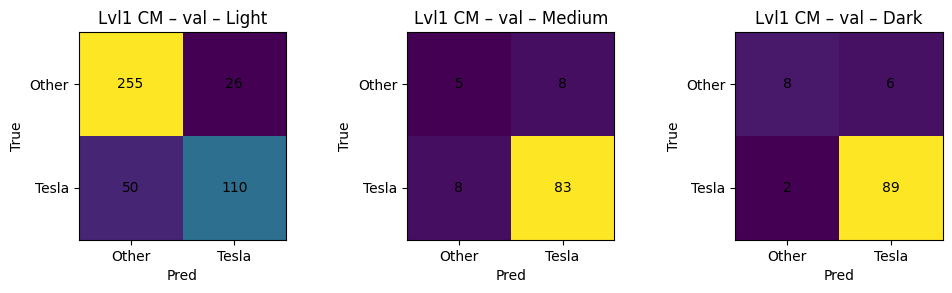

In [80]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    f1_score
)

def make_x_dataset(df, shuffle=False):
    ds = make_dataset(df, shuffle=shuffle)          # (x, y, sw)
    return ds.map(lambda x, y, sw: x)               # -> x

def predict_heads(model, df):
    x_ds = make_x_dataset(df, shuffle=False)
    preds = model.predict(x_ds, verbose=0)
    p1 = preds["lvl1"].reshape(-1)                  # sigmoid
    p2 = preds["lvl2"]                              # softmax
    return p1, p2

def plot_cm_2x2(cm, title, save_path=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.6, 3.0))

    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Other", "Tesla"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Other", "Tesla"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_xlabel("Pred")
    ax.set_ylabel("True")

    if ax is None and save_path:
        plt.tight_layout()
        plt.savefig(save_path, dpi=160)
        plt.show()

def eval_lvl1_by_lighting(model, df, lighting_col="lighting", threshold=0.5, lighting_order=("Light","Medium","Dark")):
    rows = []
    cms = {}

    # predikér én gang på hele df, så slicer vi per lighting (raskere)
    p1_all, _ = predict_heads(model, df)
    y_true_all = df["y_lvl1"].to_numpy().astype(int)
    y_pred_all = (p1_all >= threshold).astype(int)

    for light in lighting_order:
        dfi = df[df[lighting_col] == light]
        if len(dfi) == 0:
            continue

        idx = dfi.index.to_numpy()
        y_true = y_true_all[df.index.get_indexer(idx)]
        y_pred = y_pred_all[df.index.get_indexer(idx)]

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN FP],[FN TP]]
        tn, fp, fn, tp = cm.ravel()

        tpr = tp / (tp + fn) if (tp + fn) else np.nan  # recall Tesla
        tnr = tn / (tn + fp) if (tn + fp) else np.nan  # recall Other

        row = {
            "lighting": light,
            "n_total": len(dfi),
            "n_other": int((y_true == 0).sum()),
            "n_tesla": int((y_true == 1).sum()),
            "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
            "TPR": tpr,
            "TNR": tnr,
            "lvl1_bal_acc": (tpr + tnr) / 2 if np.isfinite(tpr) and np.isfinite(tnr) else np.nan,
            "lvl1_acc": accuracy_score(y_true, y_pred),
            "lvl1_f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "lvl1_maj_acc": max(int((y_true == 0).sum()), int((y_true == 1).sum())) / len(dfi),
        }
        rows.append(row)
        cms[light] = cm

    return pd.DataFrame(rows), cms

# --- Kjør + lagre ---
out_dir = Path("results") / RUN_TAG / EVAL_SPLIT / "lvl1"
out_dir.mkdir(parents=True, exist_ok=True)

df_lvl1, cm_by_light = eval_lvl1_by_lighting(model, eval_df, threshold=0.5)
df_lvl1.to_csv(out_dir / "lvl1_metrics_by_lighting.csv", index=False, encoding="utf-8")
display(df_lvl1)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.0))

for ax, light in zip(axes, ("Light","Medium","Dark")):
    if light in cm_by_light:
        plot_cm_2x2(cm_by_light[light], f"Lvl1 CM – {EVAL_SPLIT} – {light}", ax=ax)

fig.tight_layout()
fig.savefig(out_dir / "cm_lvl1_all.png", dpi=160)
plt.show()

,n_tesla,lvl2_acc,lvl2_bal_acc,lvl2_f1_macro,lvl2_maj_acc
0,342,0.412281,0.283474,0.311647,0.374269


,lighting,n_tesla,lvl2_acc,lvl2_bal_acc,lvl2_f1_macro
0,Light,160,0.462500,0.313611,0.331807
1,Medium,91,0.351648,0.155102,0.141429
2,Dark,91,0.384615,0.163124,0.140148


,class_id,class,support,precision,recall,f1
1,1,3 2024–nå,37,0.187500,0.081081,0.113208
0,0,3 2017–2023,52,0.263158,0.096154,0.140845
6,6,Y 2025-nå,49,0.636364,0.142857,0.233333
3,3,S 2016–nå,19,1.000000,0.210526,0.347826
2,2,S 2012–2015,16,1.000000,0.250000,0.400000
4,4,X,41,0.395349,0.414634,0.404762
5,5,Y 2020–2024,128,0.412245,0.789062,0.541555


,true,pred,rate,support_true
1,3 2024–nå,Y 2020–2024,0.756757,37
2,S 2012–2015,Y 2020–2024,0.750000,16
6,Y 2025-nå,Y 2020–2024,0.734694,49
0,3 2017–2023,Y 2020–2024,0.730769,52
3,S 2016–nå,Y 2020–2024,0.578947,19


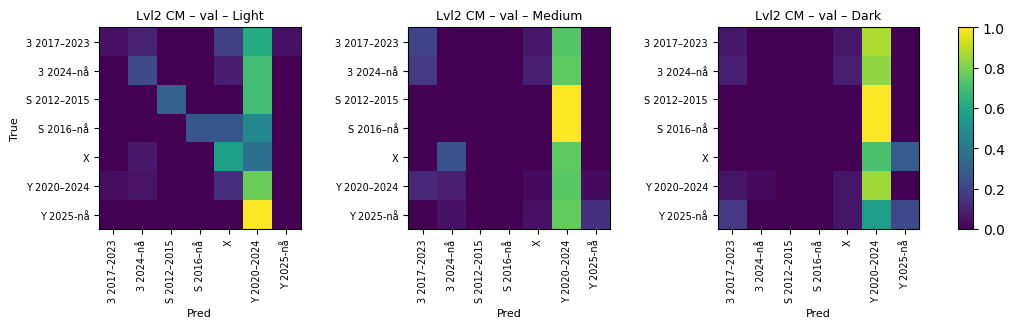

In [81]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    f1_score, precision_recall_fscore_support
)

def plot_cm_norm(cm_norm, labels, title, save_path=None, max_classes=30):
    plt.figure(figsize=(7.0, 6.0))
    plt.imshow(cm_norm, interpolation="nearest")
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=160)
    plt.show()

def eval_lvl2(model, df, lighting_col="lighting", lighting_order=("Light","Medium","Dark"), topn=8):
    # Tesla-only subset
    tesla_df = df[df["y_lvl1"].astype(int) == 1].copy()
    if len(tesla_df) == 0:
        raise ValueError("Ingen Tesla-rader i eval_df – kan ikke evaluere lvl2.")

    # Predikér én gang på hele df, så slicer vi Tesla-indeksene
    _, p2_all = predict_heads(model, df)
    idx_tesla = tesla_df.index.to_numpy()
    pos = df.index.get_indexer(idx_tesla)

    y_true = tesla_df["y_lvl2"].to_numpy().astype(int)
    y_pred = np.argmax(p2_all[pos], axis=1).astype(int)
    counts = np.bincount(y_true, minlength=num_lvl2)
    lvl2_maj_acc = counts.max() / len(y_true)

    # Overall metrics
    overall = {
        "n_tesla": len(tesla_df),
        "lvl2_acc": accuracy_score(y_true, y_pred),
        "lvl2_bal_acc": balanced_accuracy_score(y_true, y_pred),
        "lvl2_f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "lvl2_maj_acc": lvl2_maj_acc,
    }
    df_overall = pd.DataFrame([overall])

    # Per lighting metrics (Tesla-only) + CM per lighting
    rows = []
    cm_norm_by_light = {}

    for light in lighting_order:
        dfl = tesla_df[tesla_df[lighting_col] == light]
        if len(dfl) == 0:
            continue

        y_t = dfl["y_lvl2"].to_numpy().astype(int)
        pos_l = df.index.get_indexer(dfl.index.to_numpy())
        y_p = np.argmax(p2_all[pos_l], axis=1).astype(int)

        rows.append({
            "lighting": light,
            "n_tesla": len(dfl),
            "lvl2_acc": accuracy_score(y_t, y_p),
            "lvl2_bal_acc": balanced_accuracy_score(y_t, y_p),
            "lvl2_f1_macro": f1_score(y_t, y_p, average="macro", zero_division=0),
        })

        cm_l = confusion_matrix(y_t, y_p, labels=list(range(num_lvl2)))
        with np.errstate(divide="ignore", invalid="ignore"):
            cm_l_norm = cm_l / cm_l.sum(axis=1, keepdims=True)
            cm_l_norm = np.nan_to_num(cm_l_norm)
        cm_norm_by_light[light] = cm_l_norm
    df_by_light = pd.DataFrame(rows)

    # Support per klasse x lyskategori (Tesla-only)
    support_tbl = (
        tesla_df.groupby(["lvl2", lighting_col]).size()
        .unstack(lighting_col, fill_value=0)
        .reindex(index=lvl2_classes, fill_value=0)  # behold fast klasseorden
    )
    support_tbl["Total"] = support_tbl.sum(axis=1)
    support_tbl.loc["Total"] = support_tbl.sum(axis=0)

    # Per-klasse precision/recall/f1/support (overall Tesla-only)
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(num_lvl2)), zero_division=0
    )
    df_per_class = pd.DataFrame({
        "class_id": range(num_lvl2),
        "class": lvl2_classes,
        "support": sup,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }).sort_values(["recall", "support"], ascending=[True, True])

    # Confusion matrix (normalisert per sann klasse)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_lvl2)))
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = cm / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)

    # Typiske forvekslinger (topp-5 på tvers av klasser)
    confusions = []
    for i in range(num_lvl2):
        row = cm_norm[i].copy()
        row[i] = 0.0
        j = int(np.argmax(row))
        if row[j] > 0:
            confusions.append((lvl2_classes[i], lvl2_classes[j], float(row[j]), int(cm[i].sum())))
    df_confusions = pd.DataFrame(confusions, columns=["true", "pred", "rate", "support_true"]) \
                      .sort_values(["rate","support_true"], ascending=[False, False]) \
                      .head(5)

    return df_overall, df_by_light, support_tbl, df_per_class, cm_norm, df_confusions, cm_norm_by_light


# --- Kjør + lagre ---
out_dir = Path("results") / RUN_TAG / EVAL_SPLIT / "lvl2"
out_dir.mkdir(parents=True, exist_ok=True)

df_lvl2_overall, df_lvl2_by_light, support_tbl, df_lvl2_per_class, cm_norm, df_confusions, cm_norm_by_light = eval_lvl2(model, eval_df)

df_lvl2_overall.to_csv(out_dir / "lvl2_overall.csv", index=False, encoding="utf-8")
df_lvl2_by_light.to_csv(out_dir / "lvl2_metrics_by_lighting.csv", index=False, encoding="utf-8")
# #support_tbl.to_csv(out_dir / "lvl2_support_by_lighting.csv", encoding="utf-8")
df_lvl2_per_class.to_csv(out_dir / "lvl2_per_class_pr.csv", index=False, encoding="utf-8")
df_confusions.to_csv(out_dir / "lvl2_top_confusions.csv", index=False, encoding="utf-8")

display(df_lvl2_overall)
display(df_lvl2_by_light)
# display(support_tbl)
display(df_lvl2_per_class.head(10))    # “verste” recall først
display(df_confusions)

fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.6))

for k, (ax, light) in enumerate(zip(axes, ("Light", "Medium", "Dark"))):
    if light not in cm_norm_by_light:
        ax.axis("off")
        continue

    im = ax.imshow(cm_norm_by_light[light], interpolation="nearest", vmin=0, vmax=1)
    ax.set_title(f"Lvl2 CM – {EVAL_SPLIT} – {light}", fontsize=9)

    ax.set_xticks(range(num_lvl2))
    ax.set_xticklabels(lvl2_classes, rotation=90, fontsize=7)
    ax.set_yticks(range(num_lvl2))
    ax.set_yticklabels(lvl2_classes, fontsize=7)

    ax.set_xlabel("Pred", fontsize=8)

    # Bare venstre plott får "True" for å unngå overlapp
    ax.set_ylabel("True" if k == 0 else "", fontsize=8)

# Litt mer luft mellom plottene + plass til colorbar
fig.subplots_adjust(left=0.06, right=0.90, top=0.86, bottom=0.30, wspace=0.30)

# Colorbar utenfor (robust)
cax = fig.add_axes([0.92, 0.30, 0.015, 0.56])
fig.colorbar(im, cax=cax)

fig.savefig(out_dir / "cm_lvl2_norm_by_lighting.png", dpi=160)
plt.show()

In [82]:
for images, labels, weights in val_ds.take(1):
    first_image = images[2]
input_tensor = tf.expand_dims(first_image, axis=0)
predictions = model.predict(input_tensor)
print(predictions)


for images, labels, weights in val_ds.take(1):
    first_image = images[3]
input_tensor = tf.expand_dims(first_image, axis=0)
predictions = model.predict(input_tensor)
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
{'lvl1': array([[0.97612315]], dtype=float32), 'lvl2': array([[2.2678281e-01, 1.9484328e-03, 1.4689003e-04, 1.0079111e-03,
        2.2208648e-02, 7.4058801e-01, 7.3171975e-03]], dtype=float32)}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
{'lvl1': array([[0.00173125]], dtype=float32), 'lvl2': array([[0.14234525, 0.1388759 , 0.14225037, 0.14408728, 0.1454072 ,
        0.14647318, 0.1405609 ]], dtype=float32)}


2026-02-27 16:20:09.345239: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
